# Example 4.2: Jack’s Car Rental 
Jack manages two locations for a nationwide car rental company. 
Each day, some number of customers arrive at each location to rent cars.
If Jack has a car available, he rents it out and is credited \$10 by the national company.
If he is out of cars at that location, then the business is lost.
Cars become available for renting the day after they are returned.
To help ensure that cars are available where they are needed, Jack can move them between the two locations overnight, at a cost of \$2  per car moved.\
\
We assume that the number of cars requested and returned at each location are Poisson random variables, meaning that the probability that
the number is $n$ is $\frac{\lambda^n}{n!}e^{-\lambda}$, where $\lambda$ is the expected number.
Suppose $\lambda$ is 3 and 4 for rental requests at the first and second locations and 3 and 2 for returns.\
\
To simplify the problem slightly, we assume that there can be no more than 20 cars at each location (any additional cars are returned to the
nationwide company, and thus disappear from the problem) and a maximum of five cars can be moved from one location to the other in one night. We take the discount rate to be $\gamma = 0.9$ and formulate this as a continuing finite MDP, where the time steps are days, the state is the number of cars at each location at the end of the day, and the actions are the net numbers of cars moved between the two locations overnight. 

In [1]:
import math
import numpy as np

import matplotlib.pyplot as plt

In [2]:
# Parameter
lamRequest1 = 3
lamRequest2 = 4
lamReturn1 = 3
lamReturn2 = 2
rentalFee = 10
movedCost = 2
carUpperBound = 20
moveUpperBound = 5
States = [[i, j] for i in range(carUpperBound+1) for j in range(carUpperBound+1)]
Actions = [num for num in range(-5, 6)]
gamma = 0.9

In [3]:
def Poisson(lam, n):
    return math.pow(lam, n) / math.factorial(n) * math.exp(-lam)

In [4]:
ProbRequest1 = [Poisson(lamRequest1, i) for i in range(carUpperBound)]
ProbRequest1.append(1 - sum(ProbRequest1))
ProbReturn1 = [Poisson(lamReturn1, i) for i in range(carUpperBound)]
ProbReturn1.append(1 - sum(ProbReturn1))
ProbRequest2 = [Poisson(lamRequest2, i) for i in range(carUpperBound)]
ProbRequest2.append(1 - sum(ProbRequest2))
ProbReturn2 = [Poisson(lamReturn2, i) for i in range(carUpperBound)]
ProbReturn2.append(1 - sum(ProbReturn2))

In [5]:
rewards = [[min(i, j) for i in range(carUpperBound+1)] for j in range(carUpperBound+1)]
# rewards[i][j] is the reward (the number of rental cars) while there are i cars and j requests.
transform = [[[0 for i in range(carUpperBound+1)] for j in range(carUpperBound+1)] for k in range(carUpperBound+1)]
# transform[i][j][k] represents the resulting number of cars when there are i cars initially, j rental requests, and k returns
for i in range(carUpperBound+1):
    for j in range(carUpperBound+1):
        for k in range(carUpperBound+1):
            cars = i
            cars = max(cars - j, 0)
            cars = min(cars + k, 20)
            transform[i][j][k] = cars
Prob = [[[[[0 for r in range(41)] for l in range(21)] for k in range(21)] for j in range(21)] for i in range(21)]
# Prob[i][j][k][l][r] = Prob[new_state= (k, l), reward = r | old_state = (i, j)] where state = (x, y) means x cars in loc1 and y cars in loc2 
for i in range(21):
    for j in range(21):
        for k in range(21):
            for l in range(21):
                for m in range(21):
                    for n in range(21):
                        prob = ProbRequest1[k] * ProbReturn1[l] * ProbRequest2[m] * ProbReturn2[n]
                        reward = rewards[i][k] + rewards[j][m]
                        first = transform[i][k][l]
                        second = transform[j][m][n]
                        Prob[i][j][first][second][reward] += prob

In [6]:
def showPolicy(policy, count):
    policy_arr = np.array(policy)  # shape (21,21)
    fig, ax = plt.subplots(figsize=(8, 6))
    c = ax.imshow(policy_arr, origin='lower', cmap='RdBu', vmin=min(Actions), vmax=max(Actions))
    ax.set_xlabel('j (cars at location 2)')
    ax.set_xticks(range(0, carUpperBound + 1, 2))
    ax.set_ylabel('i (cars at location 1)')
    ax.set_yticks(range(0, carUpperBound + 1, 2))
    ax.set_title(f'Policy {count} (action = cars moved from loc1 to loc2)')
    fig.colorbar(c, ax=ax, label='action')

    # annotate actions
    for (i_idx, j_idx), val in np.ndenumerate(policy_arr):
        ax.text(j_idx, i_idx, f"{int(val)}", ha='center', va='center', fontsize=7, color='k')

    plt.tight_layout()
    # plt.savefig(f"figures/Policy{count}.png")
    plt.show()

0


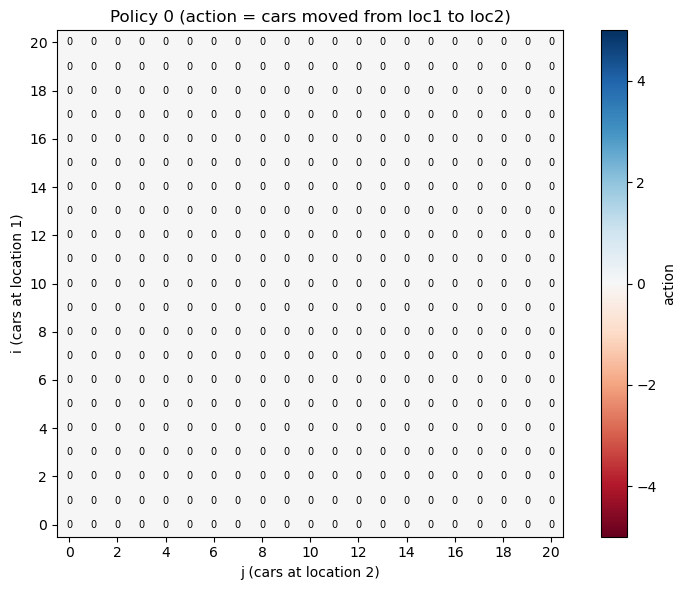

Policy Evaluation
Policy Improvement
1


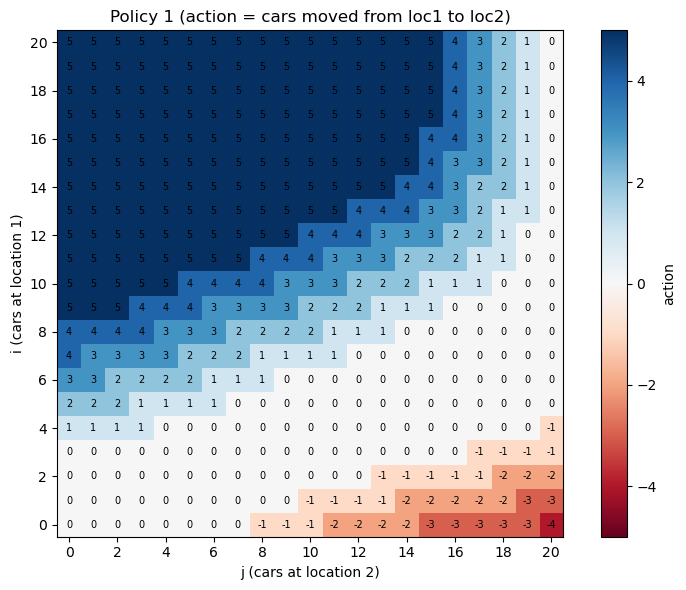

Policy Evaluation
Policy Improvement
2


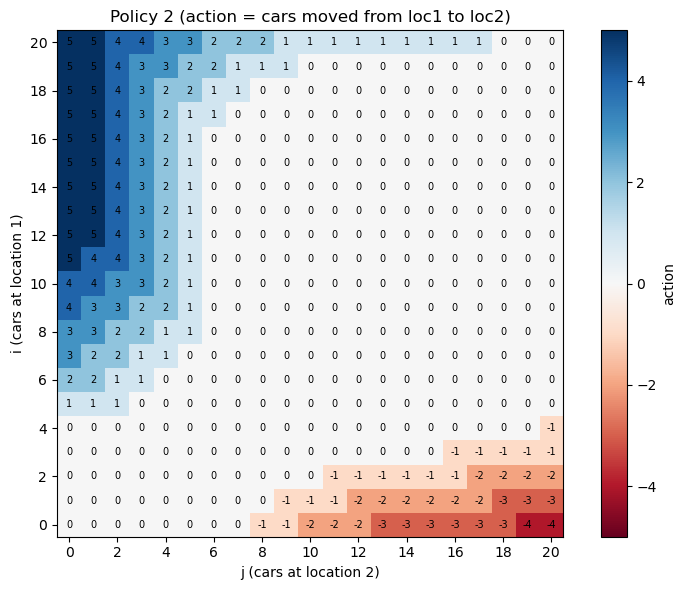

Policy Evaluation
Policy Improvement
3


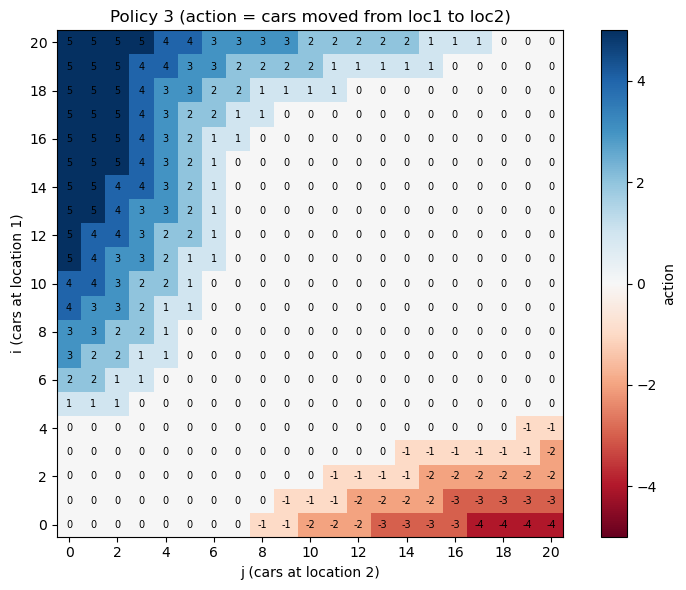

Policy Evaluation
Policy Improvement
4


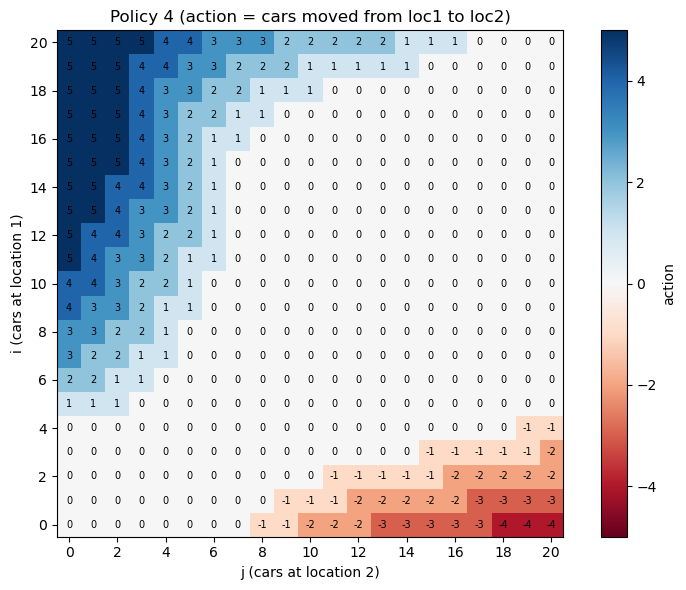

Policy Evaluation
Policy Improvement


In [7]:
policyStable = False
count = 0
values = [[0 for i in range(carUpperBound+1)] for j in range(carUpperBound+1)]
policy = [[0 for i in range(carUpperBound+1)] for j in range(carUpperBound+1)]
while not policyStable:
    print(count)
    showPolicy(policy, count)
    count += 1
    print("Policy Evaluation")
    while True:
        delta = 0
        for i in range(carUpperBound+1):
            for j in range(carUpperBound+1):
                oldValue = values[i][j]
                action = policy[i][j]
                cost = movedCost * abs(action)
                first = i - action
                second = j + action
                newValue = 0
                for k in range(carUpperBound+1):
                    for l in range(carUpperBound+1):
                        for r in range(41):
                            prob = Prob[first][second][k][l][r]
                            if prob == 0:
                                continue
                            reward = rentalFee * r
                            newValue += prob * (reward - cost + gamma * values[k][l])
                values[i][j] = newValue
                delta = max(delta, abs(oldValue - newValue))
        if delta < 1:
            break
    print("Policy Improvement")
    policyStable = True
    for i in range(carUpperBound+1):
        for j in range(carUpperBound+1):
            oldAction = policy[i][j]
            bestAction = oldAction
            bestValue = 0
            for action in Actions:
                first = i - action
                second = j + action
                if first < 0 or first > 20 or second < 0 or second > 20:
                    continue
                cost = movedCost * abs(action)
                actionValue = 0
                for k in range(carUpperBound+1):
                    for l in range(carUpperBound+1):
                        for r in range(41):
                            prob = Prob[first][second][k][l][r]
                            if prob == 0:
                                continue
                            reward = rentalFee * r
                            actionValue += prob * (reward - cost + gamma * values[k][l])
                if actionValue > bestValue:
                    bestValue = actionValue
                    bestAction = action
            if bestAction != oldAction:
                policyStable = False
            policy[i][j] = bestAction
